In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:


!ls /content/drive/My\ Drive/


 Alzehimer.zip	'Colab Notebooks'   DriveHub   ShareDrive


In [5]:
import os
import zipfile

datapath = '/content/drive/My Drive/Alzehimer.zip'

if os.path.exists(datapath):
    with zipfile.ZipFile(datapath, 'r') as zip_ref:
        zip_ref.extractall('/content/')
else:
    raise FileNotFoundError('File not found: {}'.format(datapath))

In [10]:

import os
os.chdir('/content/')


In [ ]:
data=pathlib.Path("/content/Data")
data

PosixPath('/content/Data')

In [ ]:
list(data.iterdir())


[PosixPath('/content/Data/Mild Dementia'),
 PosixPath('/content/Data/Non Demented'),
 PosixPath('/content/Data/Moderate Dementia'),
 PosixPath('/content/Data/Very mild Dementia')]

In [ ]:
ls

'Mild Dementia'/  'Moderate Dementia'/  'Non Demented'/  'Very mild Dementia'/


In [7]:

from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE #for handling imbalanced images dataset


import os
import pathlib


import cv2

# Generating new images using augmentation


In [8]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [9]:
def process_image(file_path):
    img=tf.io.read_file(file_path)
    img=tf.image.decode_jpeg(img)
    img=tf.image.resize(img,[240,240])
    img=img/255.0
    return img

In [19]:
images_dict_pipeline={
    "Mild Dementia":tf.data.Dataset.list_files("Data/Mild Dementia/*").shuffle(500).map(process_image),
    "Moderate Dementia":tf.data.Dataset.list_files("Data/Moderate Dementia/*").shuffle(500).map(process_image),
    "Non Demented":tf.data.Dataset.list_files("Data/Non Demented/*").take(16378).shuffle(500).map(process_image),
    "Very mild Dementia":tf.data.Dataset.list_files("Data/Very mild Dementia/*").shuffle(500).map(process_image)
}

In [20]:
print("Count of Mild Dementia : ",len(images_dict_pipeline["Mild Dementia"]))
print("Count of Moderate Dementia :",len(images_dict_pipeline['Moderate Dementia']))
print("Count of Non Demented : ",len(images_dict_pipeline["Non Demented"]))
print("Count of Very mild_Dementia :",len(images_dict_pipeline['Very mild Dementia']))

Count of Mild Dementia :  5002
Count of Moderate Dementia : 488
Count of Non Demented :  16378
Count of Very mild_Dementia : 13725


In [21]:
for category in images_dict_pipeline.keys():
    if(category!="Non Demented"):
        save_dir="Data/"+category

        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

        image_count_to_be_generated=len(images_dict_pipeline['Non Demented'])-len(images_dict_pipeline[category])

        print(image_count_to_be_generated," images of ",category+" to be generated")
        no_loops= (image_count_to_be_generated//len(images_dict_pipeline[category]))
        if no_loops==0:
            no_loops=1
        else:
            no_loops+=1

        for i in range(0,no_loops):
            for k, img in enumerate(images_dict_pipeline[category].take(image_count_to_be_generated)):
                img = tf.expand_dims(img, 0)
                for batch in datagen.flow(img, batch_size=1, save_to_dir=save_dir, save_prefix=category+str(i), save_format='jpg'):
                    break



11376  images of  Mild Dementia to be generated
15890  images of  Moderate Dementia to be generated
2653  images of  Very mild Dementia to be generated


Data is balanced after augmentation

# Taking 16000 images from each category¶

In [50]:
images_dict_pipeline={
    "Mild Dementia":tf.data.Dataset.list_files("Data/Mild Dementia/*").shuffle(1000).take(16000),
    "Moderate Dementia":tf.data.Dataset.list_files("Data/Moderate Dementia/*").shuffle(1000).take(16000),
    "Non Demented":tf.data.Dataset.list_files("Data/Non Demented/*").shuffle(1000).take(16000),
    "Very mild Dementia":tf.data.Dataset.list_files("Data/Very mild Dementia/*").shuffle(1000).take(16000)
}

In [65]:
print("Count of Mild Dementia : ",len(images_dict_pipeline["Mild Dementia"]))
print("Count of Moderate Dementia :",len(images_dict_pipeline['Moderate Dementia']))
print("Count of Non Demented : ",len(images_dict_pipeline["Non Demented"]))
print("Count of Very mild_Dementia :",len(images_dict_pipeline['Very mild Dementia']))

Count of Mild Dementia :  16000
Count of Moderate Dementia : 16000
Count of Non Demented :  16000
Count of Very mild_Dementia : 16000


In [66]:


def get_label(file_path):
    class_name = tf.strings.split(file_path, os.path.sep)[-2]
    if class_name == tf.constant("Mild Dementia"):
        return 0
    elif class_name == tf.constant("Moderate Dementia"):
        return 1
    elif class_name == tf.constant("Non Demented"):
        return 2
    else:
        return 3



In [67]:
def process_image(file_path):
    label=get_label(file_path)
    img=tf.io.read_file(file_path)
    img=tf.image.decode_jpeg(img)
    img=tf.image.convert_image_dtype(img,tf.float32)
    img=img/255.0
    img=tf.image.resize(img,[180,180])

    return img,label

# Preparing Data pipeline¶

### Splitting data into training and test

In [68]:
class_len=16000

train_size=0.8

ClassTrainSize=int(class_len*train_size)


train_ds=images_dict_pipeline["Mild Dementia"].take(ClassTrainSize).concatenate(images_dict_pipeline['Moderate Dementia'].take(ClassTrainSize).concatenate(images_dict_pipeline["Non Demented"].take(ClassTrainSize).concatenate(images_dict_pipeline['Very mild Dementia'].take(ClassTrainSize)))).map(process_image)
test_ds=images_dict_pipeline["Mild Dementia"].skip(ClassTrainSize).concatenate(images_dict_pipeline['Moderate Dementia'].skip(ClassTrainSize).concatenate(images_dict_pipeline["Non Demented"].skip(ClassTrainSize).concatenate(images_dict_pipeline['Very mild Dementia'].skip(ClassTrainSize)))).map(process_image)

In [69]:
batchSize=200

In [70]:
train_ds=train_ds.batch(batchSize)
test_ds=test_ds.batch(batchSize)

### Distribution of train data

class_0: 12800
class_1: 12800
class_2: 12800
class_3: 12800


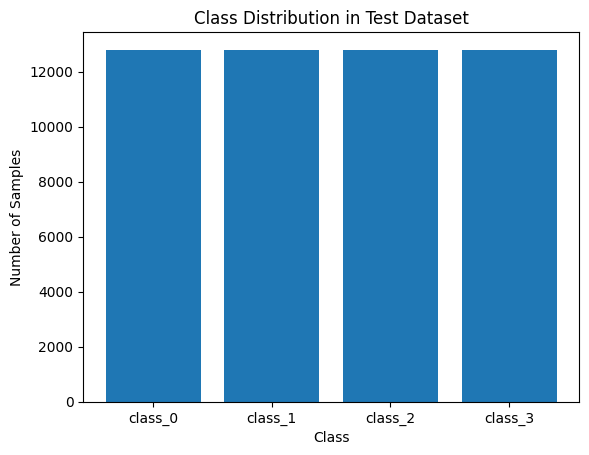

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming your test_ds elements have images and labels
# Adjust the code based on your actual dataset structure

# Initialize a dictionary to store class counts
class_counts = {'class_0': 0, 'class_1': 0, 'class_2': 0, 'class_3': 0}

# Iterate through the test_ds and count occurrences of each class
for images, labels in train_ds:
    for label in labels.numpy():
        class_name = f'class_{label}'
        class_counts[class_name] += 1

# Print the class counts
for class_name, count in class_counts.items():
    print(f'{class_name}: {count}')

# Plot class distribution
class_labels, counts = zip(*class_counts.items())
plt.bar(class_labels, counts)
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Train Dataset')
plt.show()


### Distribution of test data

class_0: 3200
class_1: 3200
class_2: 3200
class_3: 3200


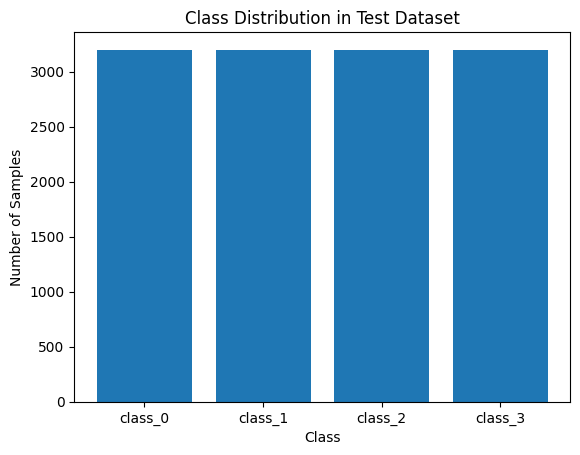

In [72]:
import matplotlib.pyplot as plt
import numpy as np

class_counts = {'class_0': 0, 'class_1': 0, 'class_2': 0, 'class_3': 0}

# Iterate through the test_ds and count occurrences of each class
for images, labels in test_ds:
    for label in labels.numpy():
        class_name = f'class_{label}'
        class_counts[class_name] += 1

for class_name, count in class_counts.items():
    print(f'{class_name}: {count}')

# Plot class distribution
class_labels, counts = zip(*class_counts.items())
plt.bar(class_labels, counts)
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Test Dataset')
plt.show()


# Creating neural network i.e CNN

In [85]:
model =Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(180, 180, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(images_dict_pipeline), activation='softmax')
])

In [86]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 89, 89, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_10 (Conv2D)          (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 43, 43, 64)        0         
 ng2D)                                                           
                                                                 
 conv2d_11 (Conv2D)          (None, 41, 41, 128)       73856     
                                                                 
 max_pooling2d_11 (MaxPooli  (None, 20, 20, 128)      

In [87]:

best_loss = float('inf')
patience = 3
no_improvement_count = 0

# Rest of your training loop
epochs = 10

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(epochs):
    print("Epoch", epoch + 1, "Started")

    # Training loop
    epoch_train_losses = []
    epoch_train_accuracies = []
    for batch in train_ds:
        X_train, y_train = batch
        loss, accuracy = model.train_on_batch(X_train, y_train)
        epoch_train_losses.append(loss)
        epoch_train_accuracies.append(accuracy)

    # Calculate average training loss and accuracy for the epoch
    avg_train_loss = np.mean(epoch_train_losses)
    avg_train_accuracy = np.mean(epoch_train_accuracies)

    # Store in lists
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_accuracy)

    print(f'Epoch {epoch + 1}, Training Loss: {avg_train_loss}, Training Accuracy: {avg_train_accuracy}')

    # Evaluation loop
    test_losses_per_epoch = []
    test_accuracies_per_epoch = []
    for batch in test_ds:
        X_test, y_test = batch
        test_loss, test_accuracy = model.test_on_batch(X_test, y_test)
        test_losses_per_epoch.append(test_loss)
        test_accuracies_per_epoch.append(test_accuracy)

    # Calculate average test loss and accuracy for the epoch
    avg_test_loss = np.mean(test_losses_per_epoch)
    avg_test_accuracy = np.mean(test_accuracies_per_epoch)

    # Store in lists
    test_losses.append(avg_test_loss)
    test_accuracies.append(avg_test_accuracy)

    print(f'Epoch {epoch + 1}, Test Loss: {avg_test_loss}, Test Accuracy: {avg_test_accuracy}')

    # Check for early stopping manually
    if avg_test_loss < best_loss:
        best_loss = avg_test_loss
        no_improvement_count = 0
    else:
        no_improvement_count += 1

    if no_improvement_count >= patience:
        print(f"Early stopping triggered after {patience} epochs of no improvement. Training stopped.")
        break


Epoch 1 Started
Epoch 1, Training Loss: 3.4874691921399648, Training Accuracy: 0.6094335937486903
Epoch 1, Test Loss: 1.3882958590984344, Test Accuracy: 0.25
Epoch 2 Started
Epoch 2, Training Loss: 1.403320004697889, Training Accuracy: 0.12109375
Epoch 2, Test Loss: 1.387468695640564, Test Accuracy: 0.25
Epoch 3 Started
Epoch 3, Training Loss: 1.4003255739808083, Training Accuracy: 0.109375
Epoch 3, Test Loss: 1.3873375952243805, Test Accuracy: 0.25
Epoch 4 Started
Epoch 4, Training Loss: 1.3998757409863174, Training Accuracy: 0.109375
Epoch 4, Test Loss: 1.3872522413730621, Test Accuracy: 0.25
Epoch 5 Started
Epoch 5, Training Loss: 1.3996485313400626, Training Accuracy: 0.109375
Epoch 5, Test Loss: 1.3871890604496002, Test Accuracy: 0.25
Epoch 6 Started
Epoch 6, Training Loss: 1.3995071952231228, Training Accuracy: 0.10546875
Epoch 6, Test Loss: 1.3871398568153381, Test Accuracy: 0.25
Epoch 7 Started
Epoch 7, Training Loss: 1.3994095060043037, Training Accuracy: 0.109375
Epoch 7, Tes

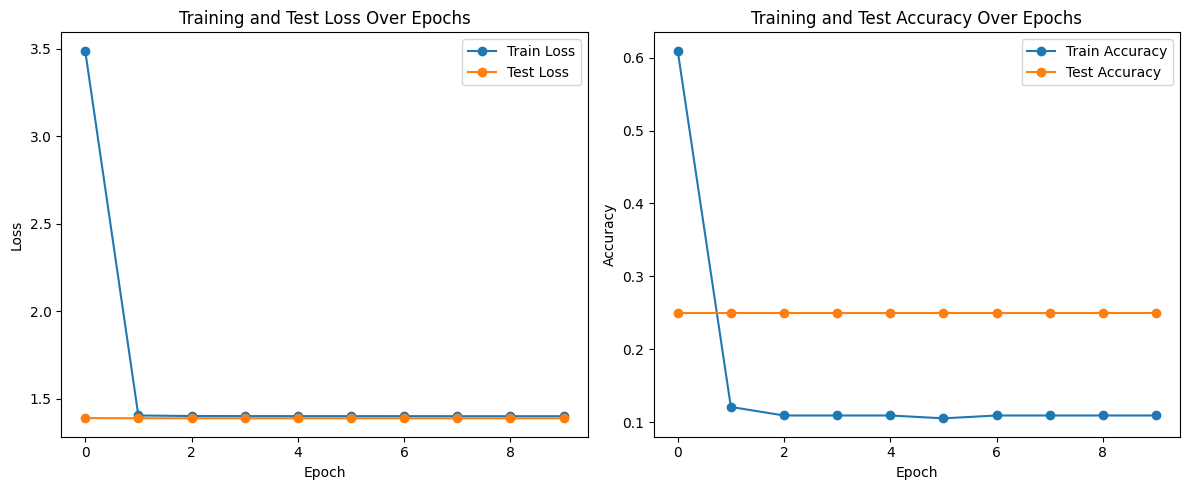

In [88]:
import matplotlib.pyplot as plt


# Plotting losses
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(test_losses, label='Test Loss', marker='o')
plt.title('Training and Test Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting accuracies
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', marker='o')
plt.plot(test_accuracies, label='Test Accuracy', marker='o')
plt.title('Training and Test Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [89]:
test_loss = 0.0
test_accuracy = 0.0
test_batches = 0

for batch in test_ds:
    X_test, y_test = batch
    loss, accuracy = model.test_on_batch(X_test, y_test)

    test_loss += loss
    test_accuracy += accuracy
    test_batches += 1

# Calculate average loss and accuracy over all test batches
final_test_loss = test_loss / test_batches
final_test_accuracy = test_accuracy / test_batches

print(f'Final Test Loss: {final_test_loss}, Final Test Accuracy: {final_test_accuracy}')


Final Test Loss: 1.3870196044445038, Final Test Accuracy: 0.25


# Classification Report

In [90]:
import numpy as np
from sklearn.metrics import classification_report


predictions = []
true_labels = []

# Iterate over batches in the test dataset
for batch in test_ds:
    X_test, y_test = batch

    batch_predictions = model.predict(X_test)
    predictions.extend(np.argmax(batch_predictions, axis=1))
    true_labels.extend(y_test)


predictions = np.array(predictions)
true_labels = np.array(true_labels)


report = classification_report(true_labels, predictions)

print(report)


7/7 [==============================] - 0s 12ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3200
           1       0.00      0.00      0.00      3200
           2       0.00      0.00      0.00      3200
           3       0.25      1.00      0.40      3200

    accuracy                           0.25     12800
   macro avg       0.06      0.25      0.10     12800
weighted avg       0.06      0.25      0.10     12800



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Confusion Matrix

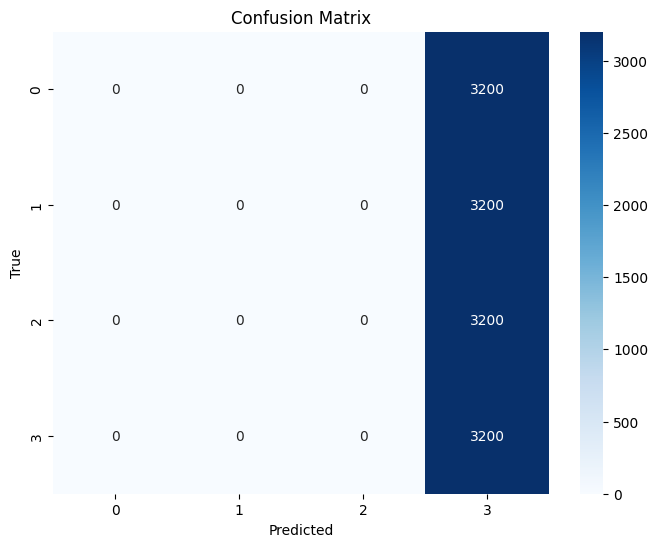

In [94]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Generate the confusion matrix
conf_matrix = confusion_matrix(true_labels, predictions)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['0', '1', '2','3'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
